In [32]:
import data_loader
import importlib
importlib.reload(data_loader)

# print(f"Box size1: {BOX_SIZE}")

# Setup
from data_loader import *
import matplotlib.pyplot as plt
import numpy as np


print("BOX_SIZE2:", BOX_SIZE)

plt.rcParams.update({'font.size': 14})


Loading bubble data...
✓ Loaded 139446 observations
Empty DataFrame
Columns: [id, x, y, area, pressure, Z]
Index: []
✓ Timesteps added: 0 to 725
✓ Identified 300 disappearing bubbles
Applying periodic boundary corrections...
✓ Periodic boundary correction applied
✓ Derived quantities computed

DATA LOADING COMPLETE
Total observations:       139,446
Unique bubbles:           400
Timesteps:                0 to 725
Disappearing bubbles:     300
Box size:                 20.203051
Initial avg area (A_0):   1.000000

Available variables:
  - df: Original dataframe
  - df_corrected: Corrected dataframe with actual_area column
  - disappearing_ids: Set of disappearing bubble IDs
  - bubbles_per_timestep: Number of bubbles at each timestep
  - avg_area_per_timestep: Average bubble area at each timestep
  - approx_avg_area: Approximate area from liquid fraction
  - A_0: Initial average bubble area
  - max_timestep: Maximum timestep
  - final_step: Final timestep
  - box_area: Total box area
  -

In [33]:
# Collect all position changes from all bubbles
all_changes_x = []
all_changes_y = []

for bubble_id, g in df_corrected.groupby("id"):
    g = g.sort_values("timestep").copy()
    
    if len(g) < 2:  # Need at least 2 points to calculate changes
        continue
        
    # Use corrected positions directly
    x = g["x"].to_numpy()
    y = g["y"].to_numpy()
    
    changes_x = np.diff(x)
    changes_y = np.diff(y)
    
    all_changes_x.extend(changes_x)
    all_changes_y.extend(changes_y)
    

# Combine x and y changes for overall displacement distribution
all_changes = np.concatenate([all_changes_x, all_changes_y])



In [34]:

# Displacement Analysis for Multiple dt Values
#dt_values = [1, 10, 25, 50, 75, 125, 200, 300, 400, 500]
dt_values = [1, 2, 5, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 120, 140, 160, 200, 250, 300, 350, 400]
# dt_values = [1, 2, 5, 10, 25, 50]


for idx, dt in enumerate(dt_values):
    all_dx, all_dy = [], []
    
    for bubble_id, g in df_corrected.groupby("id"):
        g = g.sort_values("timestep").copy()
        x, y = g["x"].to_numpy(), g["y"].to_numpy()
        
        if len(x) <= dt:
            continue
        
        dx_dt = x[dt:] - x[:-dt]
        dy_dt = y[dt:] - y[:-dt]
        
        all_dx.extend(dx_dt)
        all_dy.extend(dy_dt)
    
    all_disp = np.concatenate([all_dx, all_dy])
    print(f"Δt={dt}: n={len(all_disp)}, mean={np.mean(all_disp):.5f}, var={np.var(all_disp):.5f}")




Δt=1: n=278092, mean=0.00000, var=0.00021
Δt=2: n=277292, mean=0.00000, var=0.00059
Δt=5: n=274892, mean=0.00001, var=0.00209
Δt=10: n=270912, mean=0.00008, var=0.00502
Δt=20: n=263136, mean=0.00032, var=0.01133
Δt=30: n=255628, mean=0.00065, var=0.01783
Δt=40: n=248480, mean=0.00100, var=0.02430
Δt=50: n=241614, mean=0.00134, var=0.03075
Δt=60: n=234922, mean=0.00172, var=0.03729
Δt=70: n=228482, mean=0.00215, var=0.04368
Δt=80: n=222292, mean=0.00260, var=0.05009
Δt=90: n=216322, mean=0.00312, var=0.05643
Δt=100: n=210586, mean=0.00378, var=0.06284
Δt=120: n=199478, mean=0.00531, var=0.07600
Δt=140: n=188836, mean=0.00703, var=0.08928
Δt=160: n=178634, mean=0.00892, var=0.10173
Δt=200: n=159356, mean=0.01387, var=0.12499
Δt=250: n=137546, mean=0.01909, var=0.15740
Δt=300: n=117928, mean=0.02391, var=0.19124
Δt=350: n=100034, mean=0.02749, var=0.22006
Δt=400: n=83146, mean=0.03016, var=0.25009


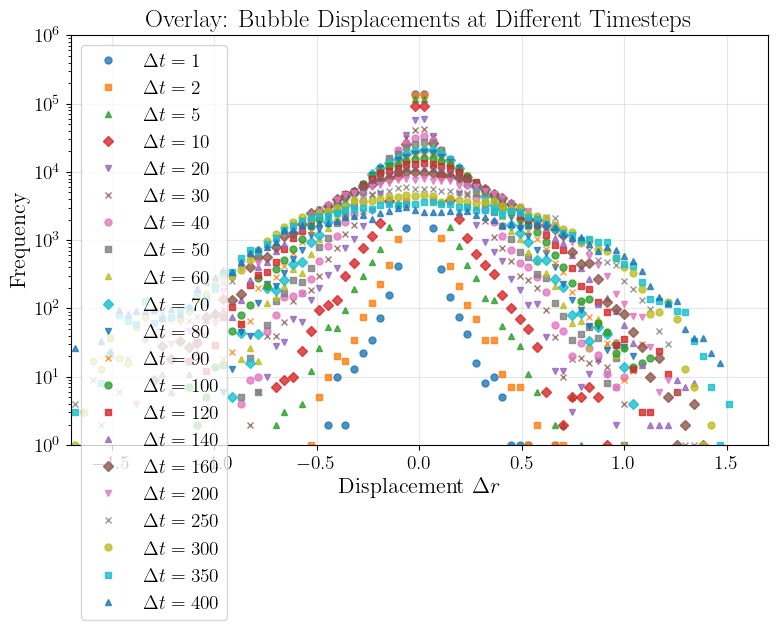

In [35]:
# Overlay Plot
plt.figure(figsize=(8, 6))

markers = ['o', 's', '^', 'D', 'v', 'x']

for idx, dt in enumerate(dt_values):
    all_dx, all_dy = [], []
    
    for bubble_id, g in df_corrected.groupby("id"):
        g = g.sort_values("timestep").copy()
        x, y = g["x"].to_numpy(), g["y"].to_numpy()
        
        if len(x) <= dt:
            continue
        
        dx_dt = x[dt:] - x[:-dt]
        dy_dt = y[dt:] - y[:-dt]
        
        all_dx.extend(dx_dt)
        all_dy.extend(dy_dt)
    
    all_disp = np.concatenate([all_dx, all_dy])
    
    counts, bin_edges = np.histogram(all_disp, bins=80, range=(-1.7, 1.7))
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    
    plt.plot(bin_centers, counts, marker=markers[idx % len(markers)],
             linestyle='none', label=rf'$\Delta t = {dt}$', alpha=0.8, markersize=5)

plt.yscale('log')
plt.xlim(-1.7, 1.7)
plt.ylim(1, 1e6)
plt.xlabel(r"Displacement $\Delta r$", fontsize=16)
plt.ylabel("Frequency", fontsize=16)
plt.title("Overlay: Bubble Displacements at Different Timesteps", fontsize=18)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
# plt.savefig("/Users/conorkirby/Library/Mobile Documents/com~apple~CloudDocs/Coding/projects/python/capstone/Figures_Sample2/03_Figures/displacement_overlay_2.png", dpi=300, bbox_inches='tight')
plt.show()

# connect with lines

/var/folders/l1/x0797x3512d9sktcpm47npbh0000gn/T/ipykernel_12796/2052986171.py:55: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(0, 1e6)  # adjust if needed after you pick top_peak


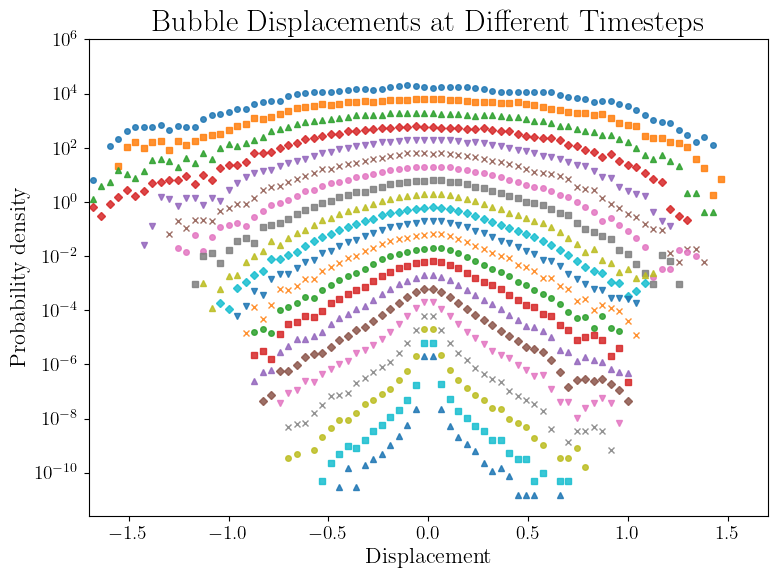

In [36]:
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Latin Modern Roman"],
})
# Overlay with centred x and staggered (log) peaks
plt.figure(figsize=(8, 6))

markers = ['o', 's', '^', 'D', 'v', 'x']

# make sure order is from largest dt (highest) to smallest dt (lowest)
dt_plot_order = sorted(dt_values, reverse=True)

# choose where you want the top peak to sit and how much to separate peaks (in log10 decades)
top_peak = 2e4        # try 2e4 or 5e4 depending on your ylim
decade_step = 0.50    # ~0.50 decades separation (~3.16x in linear). Tweak to taste.

for idx, dt in enumerate(dt_plot_order):
    all_dx, all_dy = [], []

    for bubble_id, g in df_corrected.groupby("id"):
        g = g.sort_values("timestep").copy()
        x, y = g["x"].to_numpy(), g["y"].to_numpy()
        if len(x) <= dt:
            continue
        dx_dt = x[dt:] - x[:-dt]
        dy_dt = y[dt:] - y[:-dt]
        all_dx.extend(dx_dt)
        all_dy.extend(dy_dt)

    # concatenate and centre so the peak sits at x ~ 0
    all_disp = np.concatenate([all_dx, all_dy])
    all_disp -= all_disp.mean()

    # histogram as a probability density (PDF)
    bins = 80
    rng = (-1.7, 1.7)
    counts, bin_edges = np.histogram(all_disp, bins=bins, range=rng, density=True)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    # scale so that peaks are staggered on a log axis
    current_peak = counts.max() if counts.max() > 0 else 1.0
    target_peak = top_peak * (10 ** (-decade_step * idx))  # 700 highest, then step down
    scale = target_peak / current_peak
    counts_scaled = counts * scale

    plt.plot(
        bin_centers, counts_scaled,
        marker=markers[idx % len(markers)], linestyle='none',
        label=rf'$\Delta t = {dt}$', alpha=0.85, markersize=4
    )

plt.yscale('log')
plt.xlim(-1.7, 1.7)
plt.ylim(0, 1e6)  # adjust if needed after you pick top_peak
plt.xlabel(r"Displacement", fontsize=16)
plt.ylabel("Probability density", fontsize=16)
plt.title("Bubble Displacements at Different Timesteps", fontsize=22)
# reverse legend order
handles, labels = plt.gca().get_legend_handles_labels()
plt.tight_layout()
plt.savefig("/Users/conorkirby/Library/Mobile Documents/com~apple~CloudDocs/Coding/projects/python/capstone/Figures/00_Thesis_Figures/displacement_overlay_shifted_peaks_invest.png", dpi=300, bbox_inches='tight')
plt.show()

# reverse legend order
# change dt's

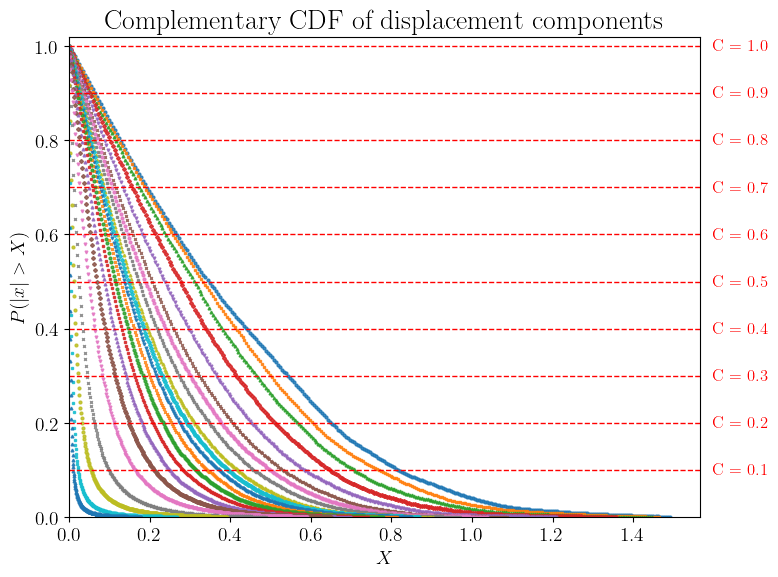

In [37]:
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Latin Modern Roman"],
})
plt.figure(figsize=(8, 6))
markers = ['o', 's', '^', 'D', 'v', 'x']

# Choose the C (probability) levels for horizontal cuts
# C_vals = [0.50, 0.45, 0.4, 0.35, 0.3, 0.25, 0.2, 0.15, 0.1, 0.05, 0.01] 
C_vals = [1.0, 0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1]  


# Plot largest dt first so it is on top in legend
dt_plot_order = sorted(dt_values, reverse=True)

for idx, dt in enumerate(dt_plot_order):
    all_dx, all_dy = [], []

    for bubble_id, g in df_corrected.groupby("id"):
        g = g.sort_values("timestep").copy()
        x, y = g["x"].to_numpy(), g["y"].to_numpy()
        if len(x) <= dt:
            continue
        dx_dt = x[dt:] - x[:-dt]
        dy_dt = y[dt:] - y[:-dt]
        all_dx.extend(dx_dt)
        all_dy.extend(dy_dt)

    # radial step sizes:
    # disp = np.sqrt(np.array(all_dx)**2 + np.array(all_dy)**2)
    disp = np.concatenate([all_dx, all_dy])

    vals = np.abs(disp) 
    vals_sorted = np.sort(vals)
    n = vals_sorted.size

    # A smooth X grid up to the 99.9th percentile
    X = np.linspace(0, np.quantile(vals_sorted, 0.999), 300)

    # Empirical CCDF: P(|x| > X)
    F = np.searchsorted(vals_sorted, X, side='right') / n 
    CCDF = 1.0 - F

    plt.plot(
        X, CCDF, marker=markers[idx % len(markers)],
        linestyle='none', ms=2, alpha=0.85
    )

# Dashed lines for C values
for C in C_vals:
    plt.axhline(y=C, color='red', linestyle='--', linewidth=1)
    plt.text(
        1.02 * plt.xlim()[1], C, f" C = {C}",
        va='center', ha='left', fontsize=12, color='red'
    )

# Axis scaling and labels
plt.ylim(0, 1.02)
plt.xlim(left=0)
plt.ylabel(r"$P(|x|>X)$", fontsize=14)
plt.xlabel(r"$X$", fontsize=14)
plt.title("Complementary CDF of displacement components", fontsize=20)
plt.tight_layout()
plt.savefig("/Users/conorkirby/Library/Mobile Documents/com~apple~CloudDocs/Coding/projects/python/capstone/Figures/00_Thesis_Figures/ccdf_displacement_components_invest.png", dpi=300, bbox_inches='tight')
plt.show()


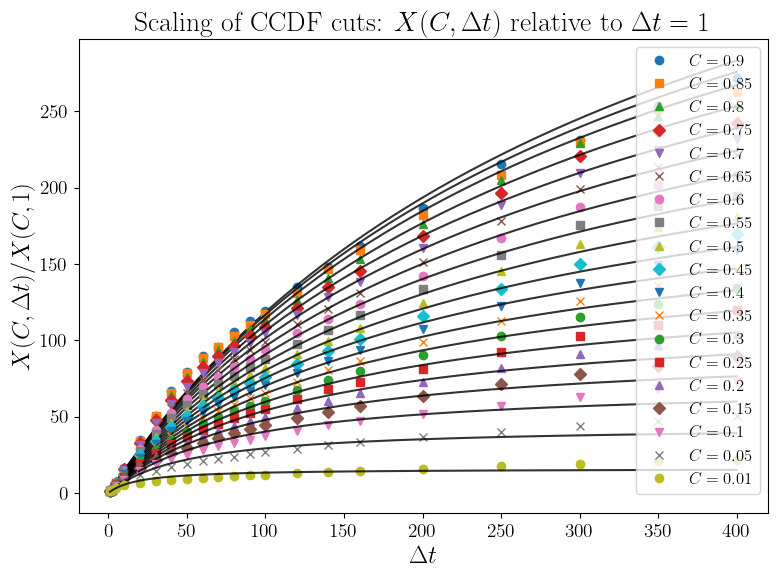

In [56]:
# === Horizontal cuts of CCDF and scaling plot ===
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Latin Modern Roman"],
})
# choose the C levels
#C_vals = [0.50, 0.45, 0.4, 0.35, 0.3, 0.25, 0.2, 0.15, 0.1, 0.05, 0.01]   
C_vals = [0.9, 0.85, 0.8, 0.75, 0.7, 0.65, 0.6, 0.55, 0.5, 0.45, 0.4, 0.35, 0.3, 0.25, 0.2, 0.15, 0.1, 0.05, 0.01]  

radial = False  # True = use r = sqrt(dx^2+dy^2), False = use |component| (Δx & Δy pooled)

def get_abs_displacements(dt):
    """Return |x| sample used in CCDF: either radial or component magnitude."""
    all_dx, all_dy = [], []
    for bubble_id, g in df_corrected.groupby("id"):
        g = g.sort_values("timestep").copy()
        x, y = g["x"].to_numpy(), g["y"].to_numpy()
        if len(x) <= dt:
            continue
        dx_dt = x[dt:] - x[:-dt]
        dy_dt = y[dt:] - y[:-dt]
        all_dx.extend(dx_dt)
        all_dy.extend(dy_dt)
    all_dx = np.asarray(all_dx)
    all_dy = np.asarray(all_dy)
    if radial:
        vals = np.sqrt(all_dx**2 + all_dy**2)
    else:
        vals = np.abs(np.concatenate([all_dx, all_dy]))
    return np.abs(vals)

# ensure dt=1 exists as the normalization reference
dt_plot_order = sorted(dt_values)
#assert dt_plot_order[0] == 1 or 1 in dt_plot_order, "Need Δt=1 in dt_values to form the ratio."

abs_samples = {}
for dt in dt_plot_order:
    v = get_abs_displacements(dt)
    if len(v):
        abs_samples[dt] = v

# compute X(C, dt) for each level and dt
X_C_dt = {C: {} for C in C_vals}
for C in C_vals:
    q = 1.0 - C  # CCDF level C corresponds to quantile q=1-C
    for dt, vals in abs_samples.items():
        if len(vals) == 0:
            continue
        X_C_dt[C][dt] = float(np.quantile(vals, q))

# make the scaling plot: X(C, dt) / X(C, 1) vs dt
plt.figure(figsize=(8, 6))
markers = ['o', 's', '^', 'D', 'v', 'x']



import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import least_squares


import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import least_squares

def y_model(dt, c1, c2):
    return (c1 * dt) / (1.0 + c2 * dt)

def hyptan_model(dt, c1, c2, c3):
    return c1 * np.tanh(c2 * dt**c3)

def log_residuals_y(p, dt, ratio):
    c1, c2 = p
    y = y_model(dt, c1, c2)
    eps = 1e-12
    return np.log(ratio + eps) - np.log(y + eps)

def log_residuals_tanh(p, dt, ratio):
    c1, c2, c3 = p
    y = hyptan_model(dt, c1, c2, c3)
    eps = 1e-12
    return np.log(ratio + eps) - np.log(y + eps)


c1_list, c2_list = [], []
for i, C in enumerate(C_vals):

    dts = np.array(sorted(X_C_dt[C].keys()), dtype=float)
    Xs  = np.array([X_C_dt[C][dt] for dt in dts], dtype=float)

    if 1 not in X_C_dt[C]:
        raise ValueError("dt=1 missing; cannot normalize.")

    ratio = Xs / float(X_C_dt[C][1])

    # exclude dt=1 from fit
    mask = dts != 0
    dts_fit = dts[mask]
    ratio_fit = ratio[mask]

    # dense dt grid for smooth curves
    dt_dense = np.logspace(np.log10(dts_fit.min()), np.log10(dts_fit.max()), 380)

    # --- fit rational model ---
    p0_y = np.array([1.0, 1.0/50.0])
    res_y = least_squares(log_residuals_y, p0_y, bounds=(0, np.inf),
                          args=(dts_fit, ratio_fit))
    c1_y, c2_y = res_y.x

    c1_list.append(c1_y)
    c2_list.append(c2_y)
    y_dense = y_model(dt_dense, c1_y, c2_y)

    # --- fit tanh model ---
    # better initial guess for tanh:
    # c1 ~ plateau ~ max(ratio), c2 ~ sets rise timescale
    p0_t = np.array([np.max(ratio_fit), 1.0/np.median(dts_fit), 1.0])
    res_t = least_squares(log_residuals_tanh, p0_t, bounds=(0, np.inf),
                          args=(dts_fit, ratio_fit))
    c1_t, c2_t, c3_t = res_t.x
    tanh_dense = hyptan_model(dt_dense, c1_t, c2_t, c3_t)

    #dts_new = dts/(((0.827*(C+1))*dts)/(1+(0.0031*C**(-0.61))))

    # plot data
    plt.plot(dts, ratio,
               marker=markers[i % len(markers)], linestyle='none',
               label=fr"$C={C}$")

    # plot fits
    plt.plot(dt_dense, y_dense, '-', color='black', alpha=0.8)
    #plt.plot(dt_dense, tanh_dense, '--', color='black', alpha=0.8, label=fr"$C={C}$ tanh: $c_1={c1_t:.3g},\,c_2={c2_t:.3g},\,c_3={c3_t:.3g}$")

plt.xlabel(r'$\Delta t$', fontsize=18)
plt.ylabel(r'$X(C,\Delta t)/X(C,1)$', fontsize=18)
plt.title('Scaling of CCDF cuts: $X(C,\Delta t)$ relative to $\Delta t=1$', fontsize=20)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig("/Users/conorkirby/Library/Mobile Documents/com~apple~CloudDocs/Coding/projects/python/capstone/Figures/00_Thesis_Figures/ccdf_cut_scaling_investigation.png", dpi=300, bbox_inches='tight')
plt.show()




c1 fit:  slope = 0.819919,  intercept = 0.834016
         c1 = 0.819919 * C + 0.834016


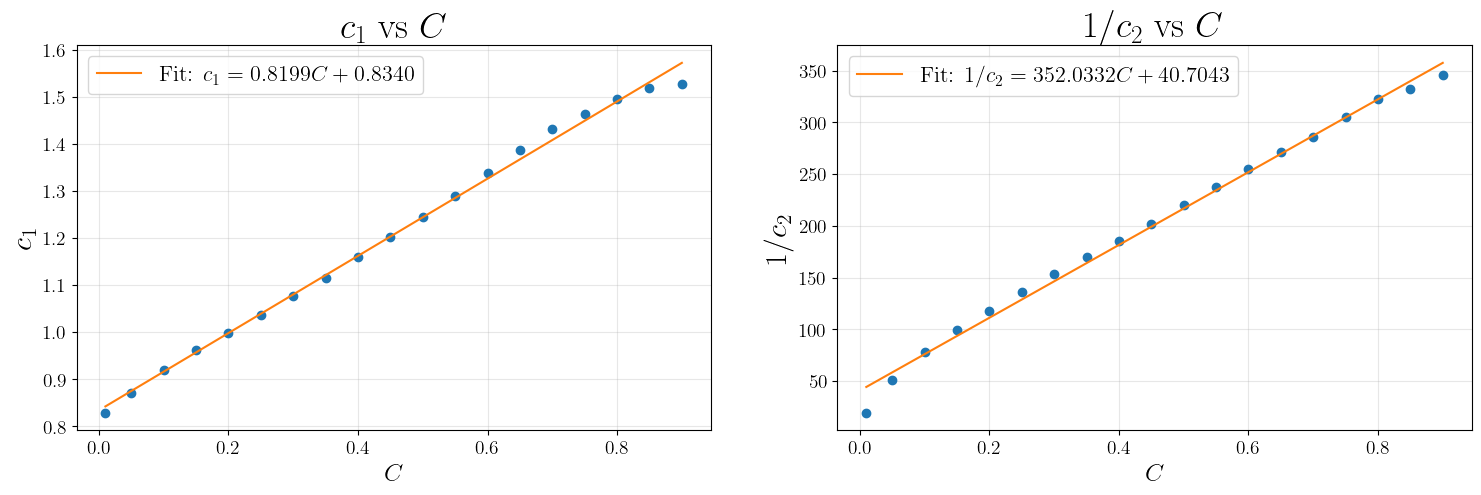

1/c2 fit: slope = 352.033231,  intercept = 40.704300
          1/c2 = 352.033231 * C + 40.704300
c2 fit:  slope = -0.212473,  intercept = 0.024567


In [57]:
from numpy.polynomial import polynomial as P
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Latin Modern Roman"],
})
C_arr  = np.array(C_vals, dtype=float)
c1_arr = np.array(c1_list, dtype=float)
c2_arr = np.array(c2_list, dtype=float)

# sort by C for a nice curve
idx = np.argsort(C_arr)
C_arr, c1_arr, c2_arr = C_arr[idx], c1_arr[idx], c2_arr[idx]

# --- Fit lines of best fit ---
m1, b1 = np.polyfit(C_arr, c1_arr, 1)
m2, b2 = np.polyfit(C_arr, 1/c2_arr, 1)

C_fit = np.linspace(C_arr.min(), C_arr.max(), 200)

fig, axs = plt.subplots(1, 2, figsize=(18, 5))
axs = axs.ravel()
# --- Plot c1 vs C ---
axs[0].plot(C_arr, c1_arr, 'o')
axs[0].plot(C_fit, m1*C_fit + b1, '-', label=f'Fit: $c_1 = {m1:.4f}C + {b1:.4f}$')
axs[0].set_xlabel(r"$C$", fontsize=18)
axs[0].set_ylabel(r"$c_1$", fontsize=22)
axs[0].set_title(r"$c_1$ vs $C$", fontsize=26)
axs[0].legend(fontsize=16)
axs[0].grid(alpha=0.3)
print(f"c1 fit:  slope = {m1:.6f},  intercept = {b1:.6f}")
print(f"         c1 = {m1:.6f} * C + {b1:.6f}")

# --- Plot 1/c2 vs C ---
axs[1].plot(C_arr, 1/c2_arr, 'o')
axs[1].plot(C_fit, m2*C_fit + b2, '-', label=f'Fit: $1/c_2 = {m2:.4f}C + {b2:.4f}$')
axs[1].set_xlabel(r"$C$", fontsize=18)
axs[1].set_ylabel(r"$1/c_2$", fontsize=22)
axs[1].set_title(r"$1/c_2$ vs $C$", fontsize=26)
axs[1].legend(fontsize=16)
axs[1].grid(alpha=0.3)
plt.savefig("/Users/conorkirby/Library/Mobile Documents/com~apple~CloudDocs/Coding/projects/python/capstone/Figures/03.2_Figures/c1_and_1-c2_vs_C_investigation.png", dpi=300, bbox_inches='tight')
plt.show()
print(f"1/c2 fit: slope = {m2:.6f},  intercept = {b2:.6f}")
print(f"          1/c2 = {m2:.6f} * C + {b2:.6f}")
print(f"c2 fit:  slope = {-m2/(b2**2):.6f},  intercept = {1/b2:.6f}")

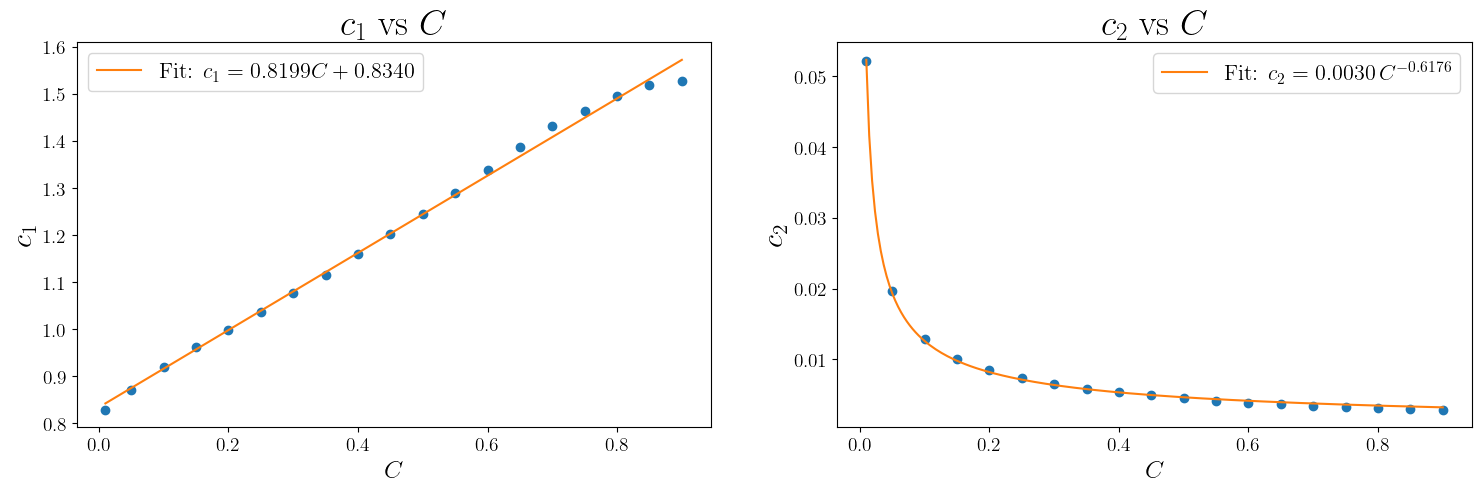

Power law fit: 1/c2 = 0.003042 * C^-0.617551


In [58]:
from scipy.optimize import curve_fit
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Latin Modern Roman"],
})
# Power law function
def power_law(x, a, b):
    return a * np.power(x, b)

C_arr  = np.array(C_vals, dtype=float)
c1_arr = np.array(c1_list, dtype=float)
c2_arr = np.array(c2_list, dtype=float)

# sort by C for a nice curve
idx = np.argsort(C_arr)
C_arr, c1_arr, c2_arr = C_arr[idx], c1_arr[idx], c2_arr[idx]

# --- Fit c1 linearly ---
m1, b1 = np.polyfit(C_arr, c1_arr, 1)

# --- Fit 1/c2 with power law (exclude C=0 if present) ---
mask = C_arr > 0
popt, pcov = curve_fit(power_law, C_arr[mask], c2_arr[mask], p0=[0.05, -0.5])
a_fit, b_fit = popt

C_fit = np.linspace(C_arr[mask].min(), C_arr.max(), 200)

fig, axs = plt.subplots(1, 2, figsize=(18, 5))

# --- Plot c1 vs C ---
axs[0].plot(C_arr, c1_arr, 'o')
axs[0].plot(C_fit, m1*C_fit + b1, '-', label=f'Fit: $c_1 = {m1:.4f}C + {b1:.4f}$')
axs[0].set_xlabel(r"$C$", fontsize=18)
axs[0].set_ylabel(r"$c_1$", fontsize=22)
axs[0].set_title(r"$c_1$ vs $C$", fontsize=26)
axs[0].legend(fontsize=16)

# --- Plot 1/c2 vs C with power law ---
axs[1].plot(C_arr, c2_arr, 'o')
axs[1].plot(C_fit, power_law(C_fit, *popt), '-',
            label=f'Fit: $c_2 = {a_fit:.4f}\\,C^{{{b_fit:.4f}}}$')
axs[1].set_xlabel(r"$C$", fontsize=18)
axs[1].set_ylabel(r"$c_2$", fontsize=22)
axs[1].set_title(r"$c_2$ vs $C$", fontsize=26)
axs[1].legend(fontsize=16)

plt.savefig("/Users/conorkirby/Library/Mobile Documents/com~apple~CloudDocs/Coding/projects/python/capstone/Figures/00_Thesis_Figures/c1_and_1_c2_vs_C_investigation.png",
            dpi=300, bbox_inches='tight')
plt.show()

print(f"Power law fit: 1/c2 = {a_fit:.6f} * C^{b_fit:.6f}")